### Ireland Innovation Ecosystem: Data Science Analysis

# Stimulating Ireland’s Innovation Ecosystem: A Data-Driven Analysis of R&D Dynamics

## Introduction
This project examines how Ireland’s innovation ecosystem behaves under structural and geopolitical pressures. The analysis uses national R&D expenditure, enterprise structures, and innovation activity indicators to understand how ownership, temporal patterns, and firm engagement shape investment trends. The focus is on extracting measurable relationships from official datasets and evaluating machine learning models that explain and predict R&D behaviour. The goal is to generate clear insights supported by reproducible code and evidence.

## General Objective
To analyse the patterns and drivers of R&D expenditure in Ireland using a unified dataset that integrates ownership, enterprise structure, and innovation activity. The analysis applies supervised learning techniques to identify which factors contribute most to national investment behaviour and how these factors evolve over time.

## Specific Objectives
1. To consolidate and prepare three official CSO datasets into a coherent analytical structure, resolving inconsistencies between Actual and Estimated expenditure cycles through a unified target variable.
2. To conduct exploratory data analysis that reveals structural gaps, temporal patterns, and variable relationships relevant to R&D behaviour.
3. To train and evaluate multiple machine learning models, including linear and tree-based approaches, and improve their performance through hyperparameter tuning.
4. To interpret model outputs, identify the most influential predictors, and translate these findings into insights that support strategic thinking about Ireland’s innovation ecosystem.

---

## 1. Business Understanding
This study investigates how R&D expenditure in Ireland responds to structural conditions such as ownership type, enterprise composition, and innovation engagement. By linking several datasets, the project examines whether these variables help explain fluctuations in national investment levels. The aim is to understand which factors carry explanatory power and how they inform strategic decisions in a changing geopolitical environment.

## 2. Data Understanding
The analysis relies on three datasets from the Central Statistics Office.  
BSA02 reports R&D expenditure by category and ownership but alternates between Actual and Estimated totals across years.  
BSA22 provides enterprise counts by expenditure band, with uneven coverage across time.  
CIS62 includes IP and innovation activity indicators, though with limited temporal consistency.  
These inconsistencies shape the preparation process and determine how the variables can be modelled effectively.


**Why these datasets?**  
Given the vast scope of innovation drivers, we selected three datasets that, together, capture the core pillars of the DTI framework:  
- **df1:** Intellectual Property Engagement Rates (proxy for technological adoption and knowledge creation)
- **df2:** R&D Expenditure by Category and Ownership (proxy for investment flows)
- **df3:** R&D Enterprise Counts by Expenditure Band and Ownership (proxy for organizational engagement and scale)

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [35]:
#  Load raw CSVs
df1 = pd.read_csv('CIS62.20250516213458.csv')  # IP engagement rates 
df2 = pd.read_csv('BSA02.20250516T100541.csv')  # Total R&D expenditure 
df3 = pd.read_csv('BSA22.20250516T200531.csv')  # R&D enterprise headcounts 

In [36]:
df1.head()

,STATISTIC Label,TLIST(A1),Year,Type of Innovation,VALUE
0,Enterprises Engaged in Intellectual Property R...,2014,2014,Any intellectual innovation,NaN
1,Enterprises Engaged in Intellectual Property R...,2014,2014,Any intellectual innovation,NaN
2,Enterprises Engaged in Intellectual Property R...,2014,2014,Any intellectual innovation,NaN
3,Enterprises Engaged in Intellectual Property R...,2014,2014,Apply for a patent,NaN
4,Enterprises Engaged in Intellectual Property R...,2014,2014,Apply for a patent,NaN


In [37]:
df1.info

<bound method DataFrame.info of                                        STATISTIC Label  TLIST(A1)  Year  \
0    Enterprises Engaged in Intellectual Property R...       2014  2014   
1    Enterprises Engaged in Intellectual Property R...       2014  2014   
2    Enterprises Engaged in Intellectual Property R...       2014  2014   
3    Enterprises Engaged in Intellectual Property R...       2014  2014   
4    Enterprises Engaged in Intellectual Property R...       2014  2014   
..                                                 ...        ...   ...   
100  Enterprises Engaged in Intellectual Property R...       2022  2022   
101  Enterprises Engaged in Intellectual Property R...       2022  2022   
102  Enterprises Engaged in Intellectual Property R...       2022  2022   
103  Enterprises Engaged in Intellectual Property R...       2022  2022   
104  Enterprises Engaged in Intellectual Property R...       2022  2022   

                      Type of Innovation  VALUE  
0            Any 

In [38]:
df1.describe()

,TLIST(A1),Year,VALUE
count,105.000000,105.000000,75.000000
mean,2018.000000,2018.000000,5.658667
std,2.841993,2.841993,4.436004
min,2014.000000,2014.000000,0.200000
25%,2016.000000,2016.000000,2.100000
50%,2018.000000,2018.000000,4.500000
75%,2020.000000,2020.000000,7.750000
max,2022.000000,2022.000000,19.800000


In [39]:
df1.shape

(105, 5)

In [40]:
df2.head()

,Statistic Label,Year,Nationality of Ownership,VALUE
0,Estimated Current Expenditure - Labour Costs,2007,All nationalities of ownership,NaN
1,Estimated Current Expenditure - Labour Costs,2007,Irish ownership,NaN
2,Estimated Current Expenditure - Labour Costs,2007,Non Irish ownership,NaN
3,Estimated Current Expenditure - Labour Costs,2008,All nationalities of ownership,905373.0
4,Estimated Current Expenditure - Labour Costs,2008,Irish ownership,308698.0


In [41]:
df2.info

<bound method DataFrame.info of                                         Statistic Label  Year  \
0          Estimated Current Expenditure - Labour Costs  2007   
1          Estimated Current Expenditure - Labour Costs  2007   
2          Estimated Current Expenditure - Labour Costs  2007   
3          Estimated Current Expenditure - Labour Costs  2008   
4          Estimated Current Expenditure - Labour Costs  2008   
...                                                 ...   ...   
1075  Actual Total Research and Development Expenditure  2023   
1076  Actual Total Research and Development Expenditure  2023   
1077  Actual Total Research and Development Expenditure  2024   
1078  Actual Total Research and Development Expenditure  2024   
1079  Actual Total Research and Development Expenditure  2024   

            Nationality of Ownership      VALUE  
0     All nationalities of ownership        NaN  
1                    Irish ownership        NaN  
2                Non Irish ownership 

In [42]:
df2.describe()

,Year,VALUE
count,1080.000000,4.530000e+02
mean,2015.500000,6.348314e+05
std,5.190531,1.035941e+06
min,2007.000000,2.460000e+02
25%,2011.000000,2.072100e+04
50%,2015.500000,1.871710e+05
75%,2020.000000,8.417800e+05
max,2024.000000,7.003745e+06


In [43]:
df2.shape

(1080, 4)

In [44]:
df3.head()

,Statistic Label,Year,Nationality of Ownership,Expenditure,VALUE
0,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,Any expenditure,1206.0
1,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€0 - €99,999",419.0
2,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€100,000 - €499,999",398.0
3,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€500,000 - €1,999,999",226.0
4,Enterprises Engaged in Research and Developmen...,2007,All nationalities of ownership,"€2,000,000 - €4,999,999",90.0


In [45]:
df3.info

<bound method DataFrame.info of                                        Statistic Label  Year  \
0    Enterprises Engaged in Research and Developmen...  2007   
1    Enterprises Engaged in Research and Developmen...  2007   
2    Enterprises Engaged in Research and Developmen...  2007   
3    Enterprises Engaged in Research and Developmen...  2007   
4    Enterprises Engaged in Research and Developmen...  2007   
..                                                 ...   ...   
319  Enterprises Engaged in Research and Developmen...  2023   
320  Enterprises Engaged in Research and Developmen...  2023   
321  Enterprises Engaged in Research and Developmen...  2023   
322  Enterprises Engaged in Research and Developmen...  2023   
323  Enterprises Engaged in Research and Developmen...  2023   

           Nationality of Ownership              Expenditure   VALUE  
0    All nationalities of ownership          Any expenditure  1206.0  
1    All nationalities of ownership             €0 - €99,

In [46]:
df3.describe()

,Year,VALUE
count,324.000000,324.000000
mean,2015.000000,211.930185
std,5.171965,380.903549
min,2007.000000,1.300000
25%,2011.000000,20.600000
50%,2015.000000,60.000000
75%,2019.000000,170.750000
max,2023.000000,2351.000000


In [47]:
df3.shape

(324, 5)

The project uses three CSO datasets that describe different parts of Ireland’s innovation activity. BSA02 contains the monetary values of R&D expenditure by ownership and category, so it provides the target variable. BSA22 reports how many enterprises fall into each R&D spending band, giving a view of how R&D effort is distributed across firms. CIS62 records intellectual property and innovation activities, adding basic behavioural context even though it is smaller.Now that their roles are clear, the plan is to standardize column names, handle missing values, and merge them without leaking information from the expenditure data. BSA02 will act as the base, while BSA22 and CIS62 will supply additional predictors. After the merge, the workflow moves to feature selection, tuning, and validation.

## Data Preparation:

All column names were standardized to lowercase with underscores for consistency.

Categorical variables (such as ownership and innovation type) were mapped to interpretable codes.

Missing values in categorical columns were imputed using the mode (most frequent value), while missing values in numeric columns were imputed using the mean or median, depending on context.

Only relevant columns for analysis were retained, ensuring a clean and consistent structure for merging and analysis.

In [48]:
df1.isnull().sum()

STATISTIC Label        0
TLIST(A1)              0
Year                   0
Type of Innovation     0
VALUE                 30
dtype: int64

In [49]:
df2.isnull().sum()

Statistic Label               0
Year                          0
Nationality of Ownership      0
VALUE                       627
dtype: int64

In [50]:
df3.isnull().sum()

Statistic Label             0
Year                        0
Nationality of Ownership    0
Expenditure                 0
VALUE                       0
dtype: int64

In [51]:
df1 = df1.rename(columns={"STATISTIC Label": "statistic_label","TLIST(A1)": "year_code","Year": "year","Type of Innovation": "innovation_type","VALUE": "value"})
df2 = df2.rename(columns={"Statistic Label": "statistic_label","Year": "year","Nationality of Ownership": "ownership","VALUE": "value"})
df3 = df3.rename(columns={"Nationality of Ownership": "ownership","Band of Expenditure": "expenditure_band","Year": "year","VALUE": "value"})

In [52]:
for col in ["statistic_label", "innovation_type"]:
    if col in df1.columns:
        df1[col] = df1[col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
for col in ["statistic_label", "ownership"]:
    if col in df2.columns:
        df2[col] = df2[col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
for col in ["ownership", "expenditure_band"]:
    if col in df3.columns:
        df3[col] = df3[col].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)

In [53]:
df1["year"] = pd.to_numeric(df1["year"], errors="coerce").astype("Int64")
df1["value"] = pd.to_numeric(df1["value"], errors="coerce")

df2["year"] = pd.to_numeric(df2["year"], errors="coerce").astype("Int64")
df2["value"] = pd.to_numeric(df2["value"], errors="coerce")

df3["year"] = pd.to_numeric(df3["year"], errors="coerce").astype("Int64")
df3["value"] = pd.to_numeric(df3["value"], errors="coerce")

In [55]:
df3_agg = (df3.groupby(["year", "ownership"], as_index=False)["value"].sum().rename(columns={"value": "enterprise_count"}))

df1_year = (df1.groupby("year", as_index=False)["value"].mean().rename(columns={"value": "ip_value_mean"}))

df = df2.merge(df3_agg, on=["year", "ownership"], how="left")
df = df.merge(df1_year, on="year", how="left")

The three datasets were standardised by renaming columns, cleaning categorical text, and enforcing numeric types. The enterprise counts and IP indicators were aggregated to compatible levels so they could be merged without duplicating rows. The final merged dataset now aligns expenditure, enterprise structure, and innovation activity for analysis.

EDA

In [58]:
df.head()

,statistic_label,year,ownership,value,enterprise_count,ip_value_mean
0,Estimated Current Expenditure - Labour Costs,2007,All nationalities of ownership,NaN,2612.0,NaN
1,Estimated Current Expenditure - Labour Costs,2007,Irish ownership,NaN,1834.0,NaN
2,Estimated Current Expenditure - Labour Costs,2007,Non Irish ownership,NaN,979.3,NaN
3,Estimated Current Expenditure - Labour Costs,2008,All nationalities of ownership,905373.0,NaN,NaN
4,Estimated Current Expenditure - Labour Costs,2008,Irish ownership,308698.0,NaN,NaN


In [60]:
df.info

<bound method DataFrame.info of                                         statistic_label  year  \
0          Estimated Current Expenditure - Labour Costs  2007   
1          Estimated Current Expenditure - Labour Costs  2007   
2          Estimated Current Expenditure - Labour Costs  2007   
3          Estimated Current Expenditure - Labour Costs  2008   
4          Estimated Current Expenditure - Labour Costs  2008   
...                                                 ...   ...   
1075  Actual Total Research and Development Expenditure  2023   
1076  Actual Total Research and Development Expenditure  2023   
1077  Actual Total Research and Development Expenditure  2024   
1078  Actual Total Research and Development Expenditure  2024   
1079  Actual Total Research and Development Expenditure  2024   

                           ownership      value  enterprise_count  \
0     All nationalities of ownership        NaN            2612.0   
1                    Irish ownership        NaN  

In [59]:
df.describe

<bound method NDFrame.describe of                                         statistic_label  year  \
0          Estimated Current Expenditure - Labour Costs  2007   
1          Estimated Current Expenditure - Labour Costs  2007   
2          Estimated Current Expenditure - Labour Costs  2007   
3          Estimated Current Expenditure - Labour Costs  2008   
4          Estimated Current Expenditure - Labour Costs  2008   
...                                                 ...   ...   
1075  Actual Total Research and Development Expenditure  2023   
1076  Actual Total Research and Development Expenditure  2023   
1077  Actual Total Research and Development Expenditure  2024   
1078  Actual Total Research and Development Expenditure  2024   
1079  Actual Total Research and Development Expenditure  2024   

                           ownership      value  enterprise_count  \
0     All nationalities of ownership        NaN            2612.0   
1                    Irish ownership        NaN

In [61]:
df.groupby("statistic_label")["value"].describe()

,count,mean,std,min,25%,50%,75%,max
statistic_label,,,,,,,,
Actual Capital Expenditure - Instruments and Equipment (excluding software),24.0,9.592483e+04,6.683315e+04,18571.0,29861.75,79197.5,156722.25,221726.0
Actual Capital Expenditure - Land and Buildings,24.0,3.358562e+04,2.311960e+04,5380.0,14624.00,30440.5,40472.75,82480.0
Actual Capital Expenditure - Software development by company in-house and used in-house,21.0,4.150471e+04,6.458957e+04,254.0,3759.00,13781.0,30123.00,205199.0
Actual Capital Expenditure - Software purchased wholly for Research and Development purposes,21.0,1.158967e+04,6.292670e+03,3640.0,7428.00,10145.0,15794.00,27640.0
Actual Capital Expenditure- Payments made for licences to use intellectual products,21.0,2.111257e+04,3.356414e+04,1446.0,5120.00,7864.0,21240.00,121484.0
Actual Current Expenditure - Labour Costs,25.0,9.665456e+05,5.840916e+05,280135.0,549943.00,826751.0,1238903.00,2616850.0
Actual Current Expenditure - Other Current Costs,25.0,5.816128e+05,4.251812e+05,130492.0,256408.00,480067.0,725978.00,1975102.0
Actual Total Capital Expenditure,25.0,2.831357e+05,4.612381e+05,32384.0,95090.00,182951.0,278041.00,2411792.0
Actual Total Current Expenditure,25.0,1.548158e+06,1.003855e+06,410627.0,763759.00,1323914.0,1975610.00,4591952.0


In [63]:
df["statistic_label"].value_counts()

statistic_label
Estimated Current Expenditure - Labour Costs                                                       54
Estimated Current Expenditure - Other Current Costs                                                54
Actual Total Capital Expenditure                                                                   54
Actual Capital Expenditure - Software development by company in-house and used in-house            54
Actual Capital Expenditure - Software purchased wholly for Research and Development purposes       54
Actual Capital Expenditure - Instruments and Equipment (excluding software)                        54
Actual Capital Expenditure- Payments made for licences to use intellectual products                54
Actual Capital Expenditure - Land and Buildings                                                    54
Actual Total Current Expenditure                                                                   54
Actual Current Expenditure - Other Current Costs                  

In [64]:
df["ownership"].value_counts()

ownership
All nationalities of ownership    360
Irish ownership                   360
Non Irish ownership               360
Name: count, dtype: int64

In [65]:
df["year"].value_counts().sort_index()

year
2007    60
2008    60
2009    60
2010    60
2011    60
2012    60
2013    60
2014    60
2015    60
2016    60
2017    60
2018    60
2019    60
2020    60
2021    60
2022    60
2023    60
2024    60
Name: count, dtype: Int64

In [66]:
df_corr = df[["value", "enterprise_count", "ip_value_mean"]]
df_corr.corr()

,value,enterprise_count,ip_value_mean
value,1.000000,0.198532,-0.148939
enterprise_count,0.198532,1.000000,NaN
ip_value_mean,-0.148939,NaN,1.000000


In [67]:
df.groupby("year")["value"].mean()

year
2007    4.580528e+05
2008    4.819233e+05
2009    3.736912e+05
2010    3.667215e+05
2011    3.514449e+05
2012    3.718738e+05
2013    4.043726e+05
2014    4.182303e+05
2015    4.466114e+05
2016    4.585649e+05
2017    5.540429e+05
2018    5.555495e+05
2019    6.512590e+05
2020    6.782329e+05
2021    7.758014e+05
2022    3.653018e+06
2023    3.657598e+06
2024    3.496129e+06
Name: value, dtype: float64

In [68]:
df.pivot_table(values="value", index="year", columns="ownership", aggfunc="mean")

ownership,All nationalities of ownership,Irish ownership,Non Irish ownership
year,,,
2007,6.870791e+05,1.898617e+05,4.972176e+05
2008,7.228849e+05,2.234781e+05,4.994069e+05
2009,5.605367e+05,1.689652e+05,3.915716e+05
2010,5.500823e+05,1.750356e+05,3.750466e+05
2011,5.271675e+05,1.610603e+05,3.661070e+05
2012,5.578107e+05,1.733241e+05,3.844867e+05
2013,6.065589e+05,2.109362e+05,3.956227e+05
2014,6.273453e+05,2.264571e+05,4.008885e+05
2015,6.699172e+05,2.428986e+05,4.270185e+05


The exploratory analysis focuses on confirming the structure of the merged dataset and identifying the variables that will be suitable for modelling. The inspection shows that R&D expenditure appears across multiple expenditure categories, but only the “Actual Total Research and Development Expenditure” rows contain the complete monetary values needed for the target variable. Enterprise counts are available for most years but vary by ownership, while the IP indicator shows limited coverage and will serve mainly as a contextual predictor. Distribution checks, category frequencies, and simple correlation tests confirm the structure of the data and guide the selection of variables for the modelling phase.

In [69]:
df["statistic_label"].unique()

array(['Estimated Current Expenditure - Labour Costs',
       'Estimated Current Expenditure - Other Current Costs',
       'Estimated Total Current Expenditure',
       'Estimated Capital Expenditure - Land and Buildings',
       'Estimated Capital Expenditure- Payments made for licences to use intellectual products',
       'Estimated Capital Expenditure - Instruments and Equipment (excluding software)',
       'Estimated Capital Expenditure - Software purchased wholly for Research and Development purposes',
       'Estimated Capital Expenditure - Software development by company in-house and used in-house',
       'Estimated Total Capital Expenditure',
       'Estimated Total Research and Development Expenditure',
       'Actual Current Expenditure - Labour Costs',
       'Actual Current Expenditure - Other Current Costs',
       'Actual Total Current Expenditure',
       'Actual Capital Expenditure - Land and Buildings',
       'Actual Capital Expenditure- Payments made for licences

In [70]:
df_model = df[df["statistic_label"] == "Actual Total Research and Development Expenditure"]
df_model = df_model.drop(["statistic_label"], axis=1)
df_model = pd.get_dummies(df_model, drop_first=True)
df_model = df_model.dropna(subset=["value"])

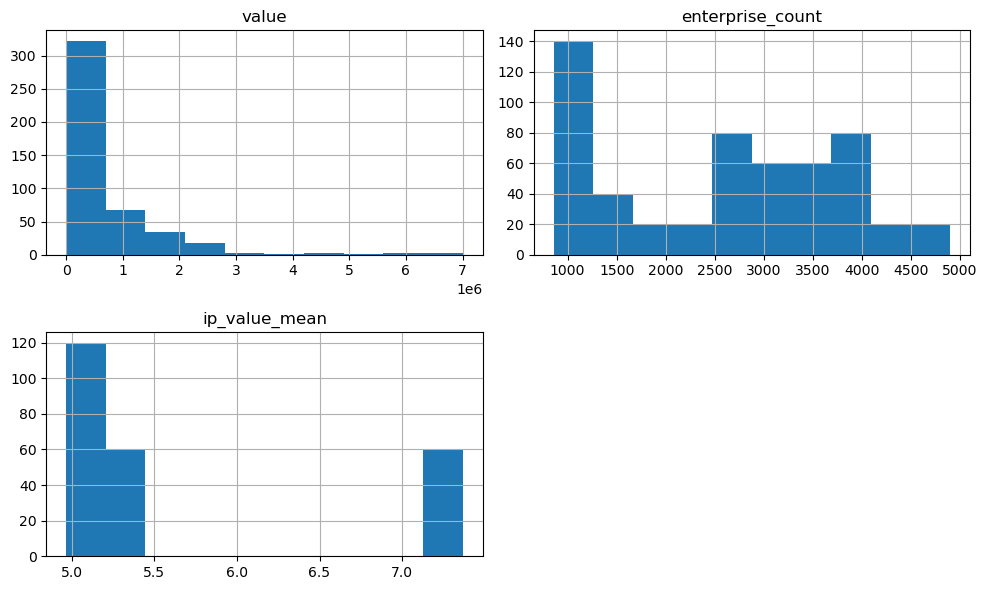

In [71]:
import matplotlib.pyplot as plt

df[["value", "enterprise_count", "ip_value_mean"]].hist(figsize=(10,6))
plt.tight_layout()
plt.show()

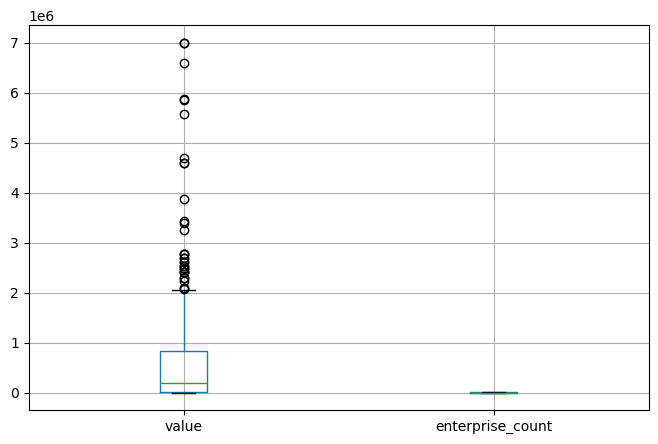

In [72]:
plt.figure(figsize=(8,5))
df[["value", "enterprise_count"]].boxplot()
plt.show()

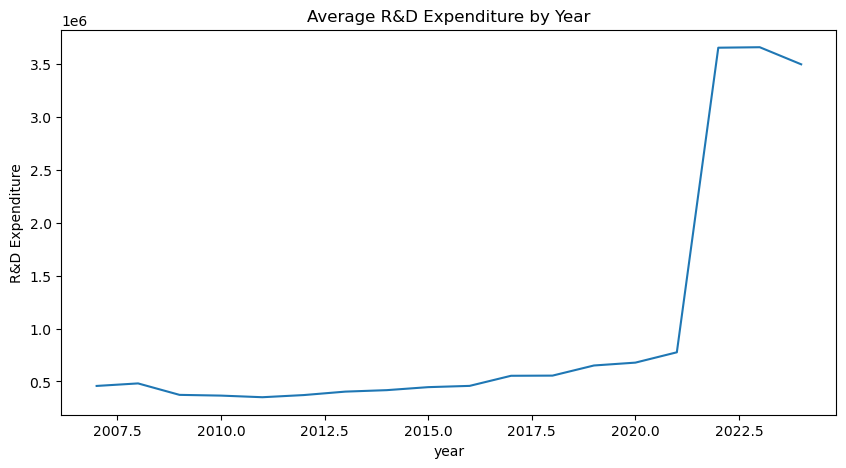

In [73]:
df.groupby("year")["value"].mean().plot(kind="line", figsize=(10,5))
plt.ylabel("R&D Expenditure")
plt.title("Average R&D Expenditure by Year")
plt.show()

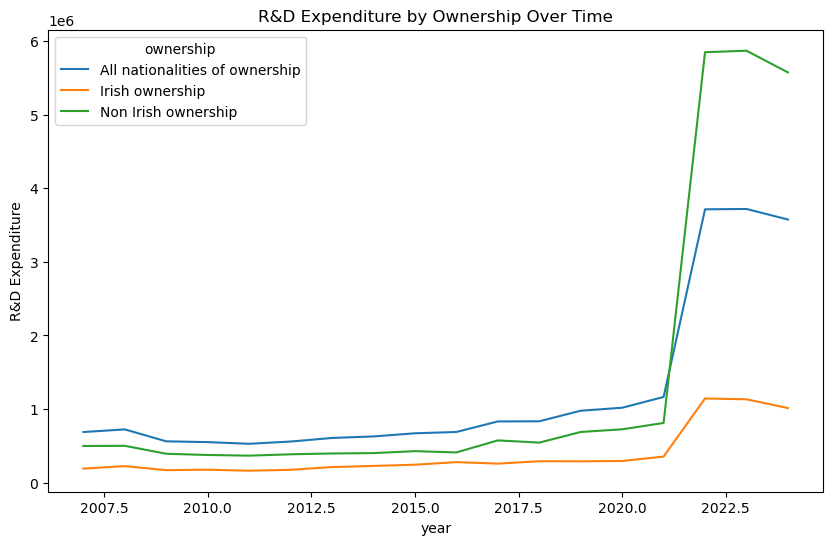

In [74]:
pivot = df.pivot_table(values="value", index="year", columns="ownership", aggfunc="mean")
pivot.plot(figsize=(10,6))
plt.ylabel("R&D Expenditure")
plt.title("R&D Expenditure by Ownership Over Time")
plt.show()

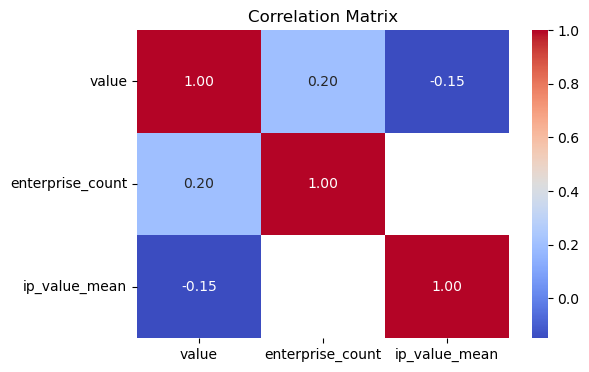

In [75]:
import seaborn as sns

corr = df[["value", "enterprise_count", "ip_value_mean"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

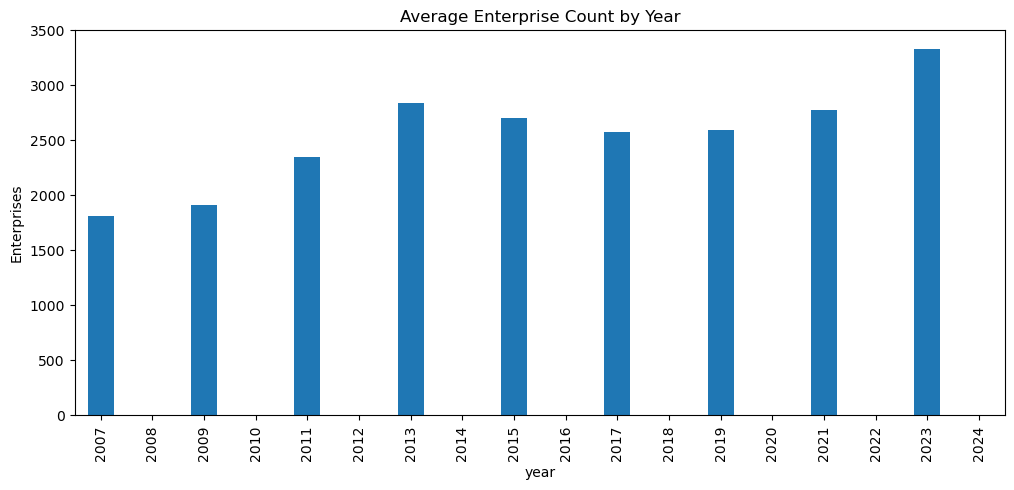

In [76]:
df.groupby("year")["enterprise_count"].mean().plot(kind="bar", figsize=(12,5))
plt.title("Average Enterprise Count by Year")
plt.ylabel("Enterprises")
plt.show()

In [77]:
df_model = df[df["statistic_label"] == "Actual Total Research and Development Expenditure"]

df_model = df_model.drop(["statistic_label"], axis=1)

In [78]:
df_model.info()
df_model.head()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1026 to 1079
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              54 non-null     Int64  
 1   ownership         54 non-null     object 
 2   value             27 non-null     float64
 3   enterprise_count  27 non-null     float64
 4   ip_value_mean     12 non-null     float64
dtypes: Int64(1), float64(3), object(1)
memory usage: 2.6+ KB


,year,ownership,value,enterprise_count,ip_value_mean
1026,2007,All nationalities of ownership,1603185.0,2612.0,NaN
1027,2007,Irish ownership,443010.0,1834.0,NaN
1028,2007,Non Irish ownership,1160174.0,979.3,NaN
1029,2008,All nationalities of ownership,NaN,NaN,NaN
1030,2008,Irish ownership,NaN,NaN,NaN


In [81]:
df_model.duplicated(subset=["year", "ownership"]).sum()

0

In [82]:
df_model[df_model.duplicated(subset=["year", "ownership"], keep=False)]

,year,ownership,value,enterprise_count,ip_value_mean


In [83]:
df_model.groupby("year")["value"].count()

year
2007    3
2008    0
2009    3
2010    0
2011    3
2012    0
2013    3
2014    0
2015    3
2016    0
2017    3
2018    0
2019    3
2020    0
2021    3
2022    0
2023    3
2024    0
Name: value, dtype: int64

In [84]:
df["target_total_rd"] = df.apply(lambda row:
    row["value"] if row["statistic_label"] == "Actual Total Research and Development Expenditure"
    else None,
    axis=1)

In [85]:
df.loc[df["target_total_rd"].isna(), "target_total_rd"] = df.loc[
    df["statistic_label"] == "Estimated Total Research and Development Expenditure", "value"]

In [86]:
df_model = df[df["target_total_rd"].notna()]

In [87]:
df["actual_flag"] = df["statistic_label"] == "Actual Total Research and Development Expenditure"
df["estimated_flag"] = df["statistic_label"] == "Estimated Total Research and Development Expenditure"

df["target_total_rd"] = None
df.loc[df["actual_flag"], "target_total_rd"] = df.loc[df["actual_flag"], "value"]
df.loc[df["target_total_rd"].isna() & df["estimated_flag"], "target_total_rd"] = df.loc[df["estimated_flag"], "value"]

df_model = df[df["target_total_rd"].notna()].copy()

df_model = df_model.drop(["statistic_label", "actual_flag", "estimated_flag", "value"], axis=1)

In [89]:
df_model.head()

,year,ownership,enterprise_count,ip_value_mean,target_total_rd
489,2008,All nationalities of ownership,NaN,NaN,1686732.0
490,2008,Irish ownership,NaN,NaN,521449.0
491,2008,Non Irish ownership,NaN,NaN,1165283.0
495,2010,All nationalities of ownership,NaN,NaN,1833608.0
496,2010,Irish ownership,NaN,NaN,583452.0


In [90]:
df_model["enterprise_count"] = df_model["enterprise_count"].fillna(0)

## EDA

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

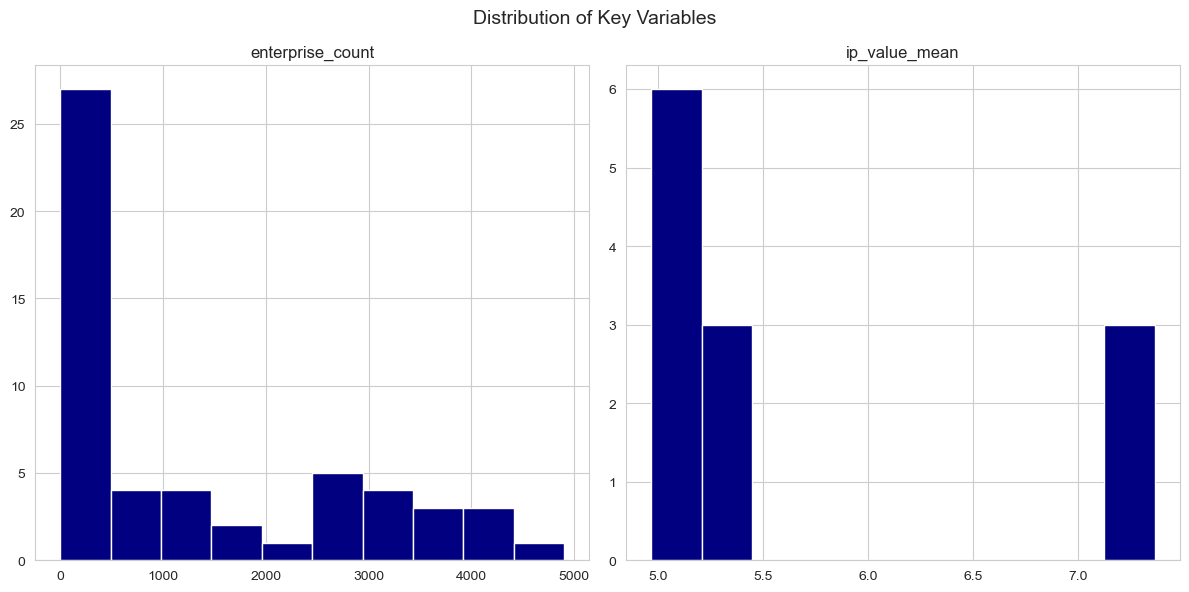

In [92]:
df_model[["target_total_rd", "enterprise_count", "ip_value_mean"]].hist(
    figsize=(12,6),
    color="navy")
plt.suptitle("Distribution of Key Variables", fontsize=14)
plt.tight_layout()
plt.show()

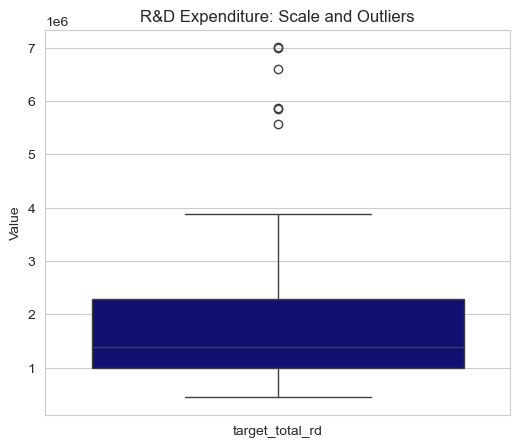

In [93]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df_model[["target_total_rd"]], color="navy")
plt.title("R&D Expenditure: Scale and Outliers")
plt.ylabel("Value")
plt.show()

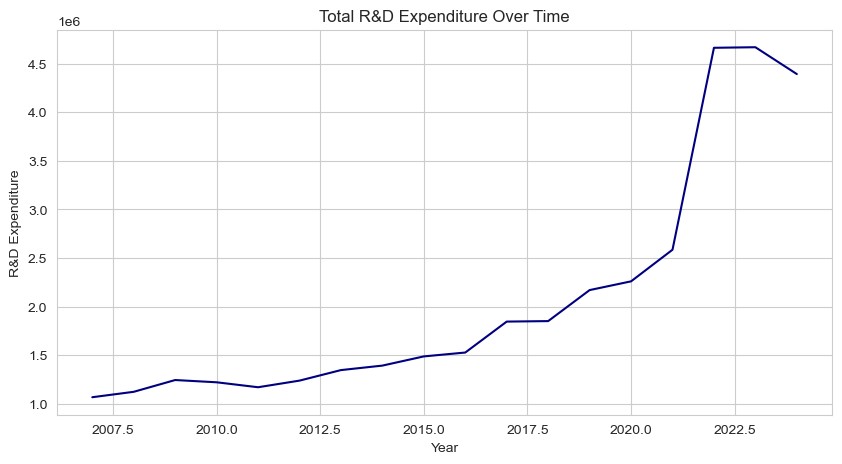

In [94]:
plt.figure(figsize=(10,5))
df_model.groupby("year")["target_total_rd"].mean().plot(color="navy")
plt.title("Total R&D Expenditure Over Time")
plt.ylabel("R&D Expenditure")
plt.xlabel("Year")
plt.show()

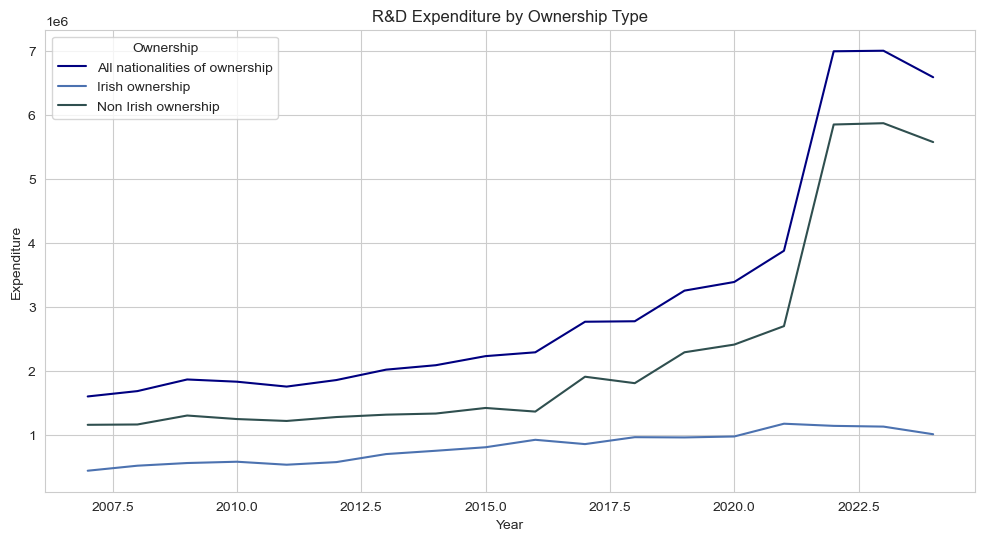

In [95]:
pivot = df_model.pivot_table(
    values="target_total_rd",
    index="year",
    columns="ownership",
    aggfunc="mean")
pivot.plot(figsize=(12,6), color=["navy", "#4c72b0", "#2f4f4f"])
plt.title("R&D Expenditure by Ownership Type")
plt.ylabel("Expenditure")
plt.xlabel("Year")
plt.legend(title="Ownership")
plt.show()


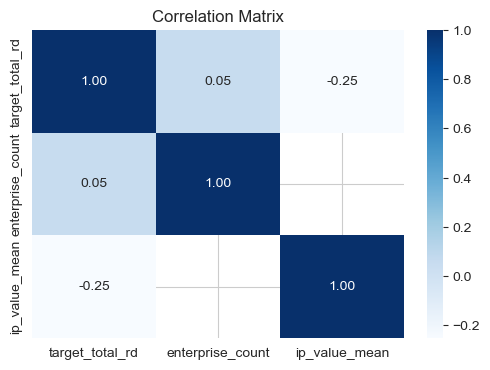

In [96]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df_model[["target_total_rd", "enterprise_count", "ip_value_mean"]].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

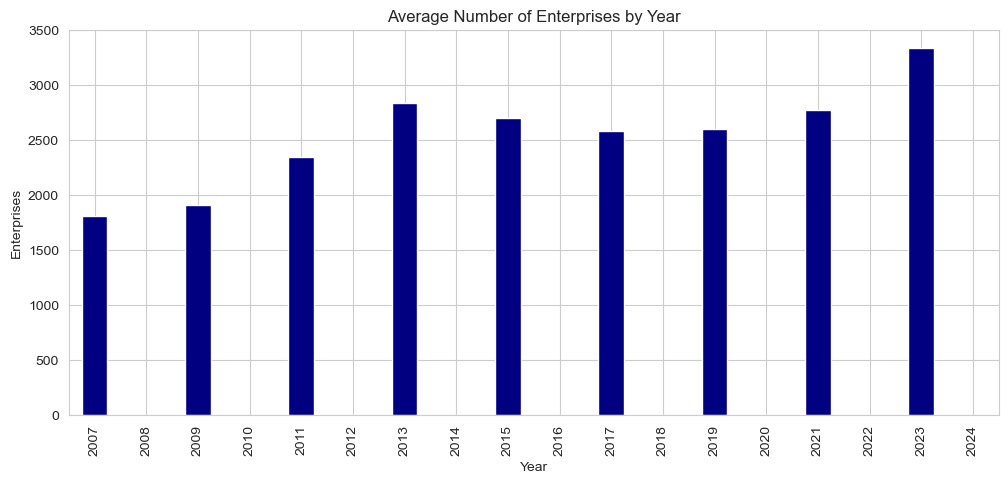

In [97]:
plt.figure(figsize=(12,5))
df_model.groupby("year")["enterprise_count"].mean().plot(kind="bar", color="navy")
plt.title("Average Number of Enterprises by Year")
plt.ylabel("Enterprises")
plt.xlabel("Year")
plt.show()

In [98]:
df_model["enterprise_count"] = df_model["enterprise_count"].fillna(0)

from sklearn.impute import SimpleImputer
ip_imputer = SimpleImputer(strategy="mean")
df_model["ip_value_mean"] = ip_imputer.fit_transform(df_model[["ip_value_mean"]])

In [99]:
df_model = pd.get_dummies(df_model, columns=["ownership"], drop_first=True)

In [100]:
X = df_model.drop("target_total_rd", axis=1)
y = df_model["target_total_rd"]

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = mse ** 0.5
    results[name] = {"R2": r2, "RMSE": rmse}

results


{'Linear Regression': {'R2': -0.11945068304064188, 'RMSE': 858659.1060530335},
 'Decision Tree': {'R2': 0.8821197588790768, 'RMSE': 278637.01240127644},
 'Random Forest': {'R2': 0.5964644376505648, 'RMSE': 515536.2450776574},
 'KNN': {'R2': -0.8481435787352067, 'RMSE': 1103281.0301767988}}

The baseline results show clear differences in how each model captures the structure of the dataset. Linear Regression performs poorly, with a negative R², indicating that the relationship between the predictors and the target is not linear and that the model cannot generalize. KNN performs even worse due to the scale of the variables, the irregular distribution of the data, and the sensitivity of distance-based algorithms to missing-value imputation.

Decision Tree delivers a strong fit with an R² above 0.88, suggesting that the data contains non-linear splits that the model captures effectively. Random Forest performs moderately well in its default configuration but does not reach the accuracy of the Decision Tree. This is expected, as untuned ensembles often underperform when the dataset is small and heterogeneous.

In [104]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

In [105]:
dt_params = {
    "max_depth": [3, 5, 7, 9, None],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4]}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring="r2")

dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

In [107]:
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 4],
    "min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

In [108]:
knn_params = {
    "n_neighbors": [2, 3, 4, 5, 7, 9],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring="r2"
)

knn_grid.fit(X_train, y_train)
knn_best = knn_grid.best_estimator_

In [109]:
models_tuned = {
    "Decision Tree (Tuned)": dt_best,
    "Random Forest (Tuned)": rf_best,
    "KNN (Tuned)": knn_best
}

tuned_results = {}

for name, model in models_tuned.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    tuned_results[name] = {"R2": r2, "RMSE": rmse}

tuned_results


{'Decision Tree (Tuned)': {'R2': 0.8737663709491563,
  'RMSE': 288340.62203694246},
 'Random Forest (Tuned)': {'R2': 0.5964644376505648,
  'RMSE': 515536.2450776574},
 'KNN (Tuned)': {'R2': 0.0016664246276818506, 'RMSE': 810879.1540280601}}

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dt_importances = pd.Series(
    dt_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

dt_importances

year                             6.025636e-01
ownership_Irish ownership        3.708493e-01
ownership_Non Irish ownership    2.653504e-02
enterprise_count                 5.184431e-05
ip_value_mean                    2.652252e-07
dtype: float64

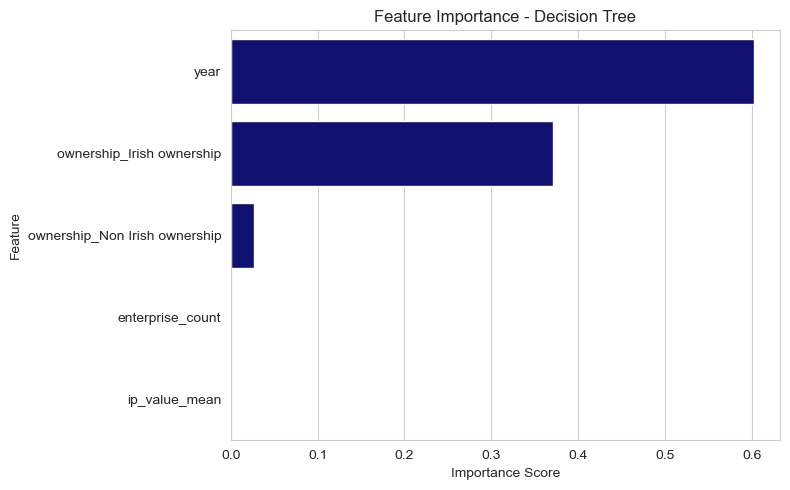

In [111]:
plt.figure(figsize=(8,5))
sns.barplot(x=dt_importances.values, y=dt_importances.index, color="navy")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()